/home/edwin/Desktop/ROV/sandbox/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


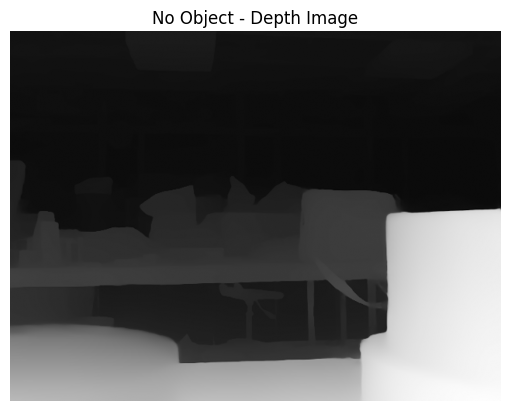

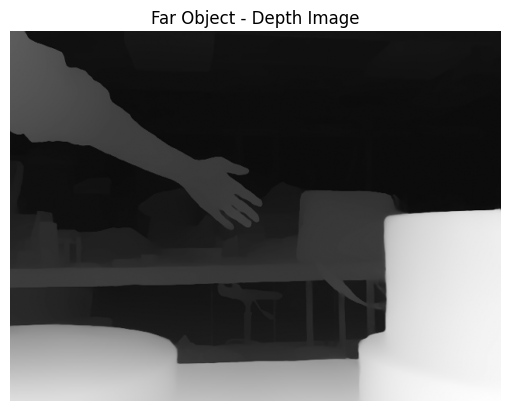

130.43496245955336
no


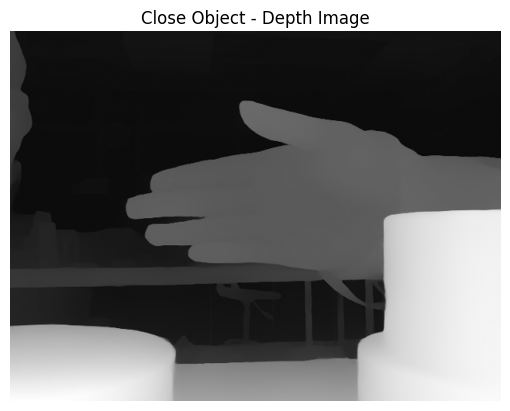

155.66229826356806
yes


In [1]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import cv2
from matplotlib import pyplot as plt
import time
no_obj_path = "PIC/no_obj.png"
far_obj_path = "PIC/far_obj.png"
close_obj_path = "PIC/close_obj.png"
no_obj = Image.open(no_obj_path).convert("RGB")
far_obj = Image.open(far_obj_path).convert("RGB")
close_obj = Image.open(close_obj_path).convert("RGB")

image_processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")
model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")

images = [no_obj, far_obj, close_obj]
titles = ["No Object", "Far Object", "Close Object"]
i = 0
for img, title in zip(images, titles):
    # prepare image for the model
    inputs = image_processor(images=img, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # interpolate to original size and visualize the prediction
    post_processed_output = image_processor.post_process_depth_estimation(
        outputs,
        target_sizes=[(img.height, img.width)],
    )

    predicted_depth = post_processed_output[0]["predicted_depth"]
    depth = (predicted_depth - predicted_depth.min()) / (predicted_depth.max() - predicted_depth.min())
    depth = depth.detach().cpu().numpy() * 255
    depth = Image.fromarray(depth.astype("uint8"))

    # Convert PIL image to numpy array
    depth_np = np.array(depth)


    plt.imshow(depth_np, cmap='gray')
    plt.title(f'{title} - Depth Image')
    plt.axis('off')
    plt.show()
    
    if i == 0:
        prev_depth_np = depth_np
    elif i > 0:
        threshold = 135
        current_depth_np = depth_np
        diff = current_depth_np - prev_depth_np
        print(np.mean(diff))
        if np.mean(diff) > threshold:
            print("yes")
        else:
            print("no")
    i += 1
    


 86.48 |  86.81 |  85.66 |  84.56 |  83.61 |  82.79 |  81.77 |  80.72 |  79.97 |  79.64 |  79.38 |  79.03 |  78.91 |  78.70
 85.40 |  85.64 |  84.14 |  83.01 |  82.00 |  81.00 |  79.93 |  79.05 |  78.38 |  78.16 |  77.84 |  77.62 |  77.48 |  77.46
 82.69 |  83.05 |  82.10 |  81.04 |  79.79 |  78.97 |  78.16 |  77.42 |  76.63 |  76.39 |  76.16 |  76.03 |  75.77 |  75.60
 79.33 |  79.86 |  42.29 |  70.70 |  77.55 |  76.87 |  76.31 |  75.70 |  74.98 |  74.54 |  74.28 |  74.05 |  73.89 |  62.17
 76.37 |  76.31 |  57.59 |  68.81 |  75.46 |  75.08 |  74.58 |  74.04 |  73.52 |  73.04 |  72.52 |  72.38 |  70.29 |  42.11
 76.67 |  76.15 |  84.58 |  76.39 |  73.79 |  73.46 |  72.88 |  72.29 |  71.79 |  71.38 |  70.84 |  70.63 |  64.55 |  31.09
 74.53 |  74.11 |  79.61 |  72.98 |  72.42 |  71.80 |  70.97 |  70.46 |  70.26 |  69.76 |  69.38 |  69.20 |  58.29 |  25.76
 72.24 |  72.35 |  75.79 |  71.41 |  70.84 |  70.21 |  69.54 |  69.24 |  69.02 |  68.56 |  67.98 |  67.47 |  51.59 |  22.02
 67.64 |

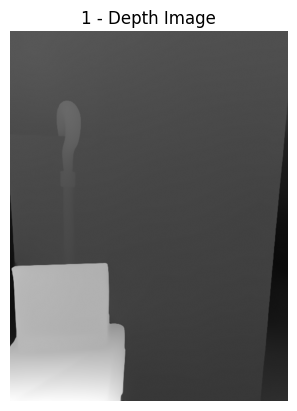

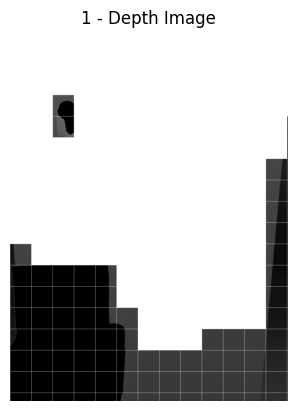

 87.94 |  45.38 |  36.41 |  28.96 |  32.30 |  41.10 |  42.22 |  42.48 |  42.66 |  41.73 |  34.93 |  41.36 |  32.27 |  32.18
 88.33 |  69.72 |  38.41 |  24.64 |  25.27 |  30.20 |  34.05 |  33.99 |  33.77 |  29.86 |  30.37 |  32.33 |  26.35 |  25.31
 88.69 |  70.67 |  52.67 |  24.41 |  22.62 |  22.41 |  25.50 |  25.51 |  24.93 |  21.95 |  22.96 |  26.00 |  24.71 |  24.38
 88.56 |  70.66 |  54.71 |  36.47 |  18.36 |  16.92 |  17.14 |  16.69 |  16.55 |  17.54 |  22.20 |  22.95 |  21.60 |  20.31
 87.98 |  70.74 |  54.16 |  37.08 |  20.85 |  12.28 |  11.58 |  12.04 |  12.29 |  13.23 |  13.88 |  13.19 |  13.44 |  13.83
 87.68 |  71.13 |  54.63 |  36.78 |  22.13 |  13.43 |  11.06 |  11.72 |  16.86 |  23.89 |  23.73 |  16.95 |  12.31 |  13.00
 88.00 |  71.78 |  55.60 |  36.82 |  22.62 |  14.10 |  11.00 |  12.04 |  21.56 |  39.29 |  46.77 |  11.04 |   8.97 |  13.38
 88.00 |  70.99 |  55.40 |  36.81 |  23.00 |  14.41 |  13.16 |  25.14 |  34.02 |  54.58 |  56.95 |   0.47 |   7.43 |  19.40
 86.69 |

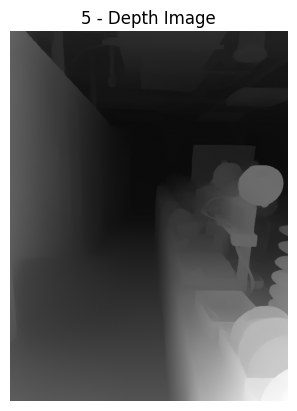

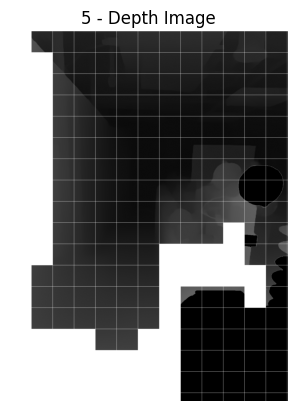

 69.42 |  70.26 |  68.83 |  65.55 |  58.80 |  50.20 |  42.56 |  41.06 |  45.46 |  42.87 |  41.70 |  45.55 |  43.68 |  43.65
 48.65 |  53.64 |  54.43 |  53.86 |  51.49 |  48.79 |  45.95 |  52.31 |  12.27 |   2.48 |   2.57 |  36.51 |  39.48 |  39.70
 34.96 |  32.96 |  23.97 |  25.68 |  28.59 |  31.56 |  33.46 |  45.59 |  62.59 |  64.72 |  53.32 |  38.82 |  27.60 |  27.58
 51.20 |  47.75 |  38.29 |  28.95 |  21.93 |  17.15 |  12.56 |  15.93 |  20.95 |  19.43 |  14.66 |  17.47 |  28.86 |  31.82
 49.32 |  48.95 |  43.89 |  37.26 |  33.46 |  31.02 |  28.34 |  20.85 |  11.59 |   6.39 |   3.58 |   3.21 |   4.04 |   4.75
 46.76 |  45.81 |  41.66 |  36.00 |  31.78 |  29.42 |  27.43 |  19.81 |  12.55 |   6.17 |   3.05 |   2.00 |   2.85 |   3.75
 44.13 |  44.03 |  40.49 |  36.63 |  35.81 |  41.11 |  30.21 |  27.60 |  22.61 |  19.27 |   7.73 |   4.12 |   3.10 |   6.78
 41.99 |  45.59 |  50.56 |  37.55 |  42.63 |  35.40 |  33.74 |  31.99 |  43.18 |  42.59 |  27.48 |  22.41 |  40.43 |  50.88
 56.82 |

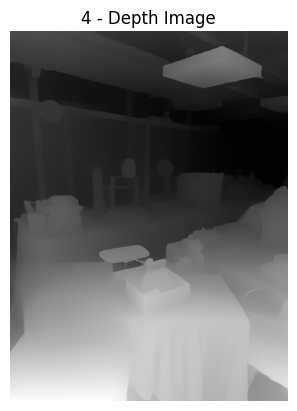

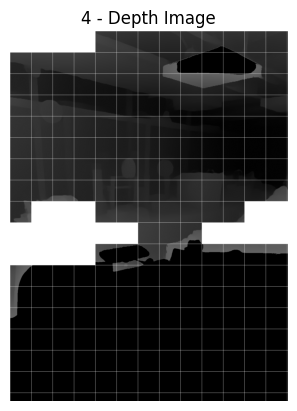

 18.44 |  18.30 |  18.55 |  18.71 |  24.58 |  26.15 |  26.19 |  21.01 |  18.44 |  18.04 |  17.97 |  18.06 |  18.15 |  19.89 |  21.03 |  20.48 |  18.95 |  18.37
 16.61 |  16.45 |  16.40 |  16.60 |  17.97 |  19.42 |  19.68 |  17.28 |  16.24 |  16.18 |  15.97 |  15.94 |  16.41 |  17.81 |  18.04 |  17.68 |  16.26 |  15.63
 14.25 |  14.87 |  14.44 |  14.17 |  13.95 |  13.69 |  13.92 |  13.64 |  13.71 |  13.44 |  13.25 |  13.38 |  13.26 |  13.01 |  13.47 |  13.90 |  13.27 |  12.63
 13.66 |  13.47 |  13.35 |  13.78 |  13.49 |  13.11 |  13.21 |  13.38 |  13.35 |  12.96 |  12.70 |  12.62 |  12.64 |  11.90 |  12.00 |  11.67 |  11.67 |  11.96
 16.36 |  12.97 |  13.00 |  12.93 |  12.82 |  12.78 |  12.86 |  13.00 |  12.71 |  12.29 |  12.00 |  12.00 |  12.11 |  11.04 |  11.24 |  11.00 |  11.00 |  11.34
 22.56 |  13.61 |  16.08 |  16.90 |  14.04 |  20.01 |  20.93 |  17.49 |  19.17 |  19.40 |  23.09 |  25.71 |  24.72 |  18.40 |  11.23 |  11.18 |  11.05 |  11.16
 26.75 |  25.22 |  15.45 |  16.26 |  19.

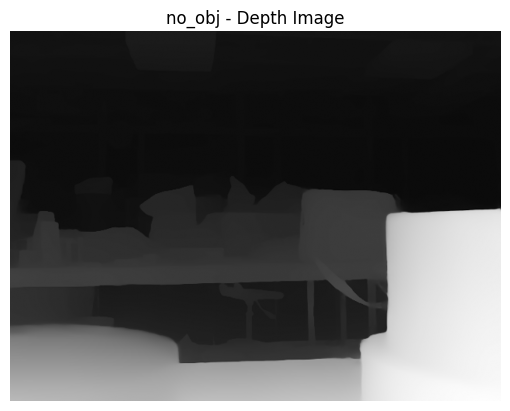

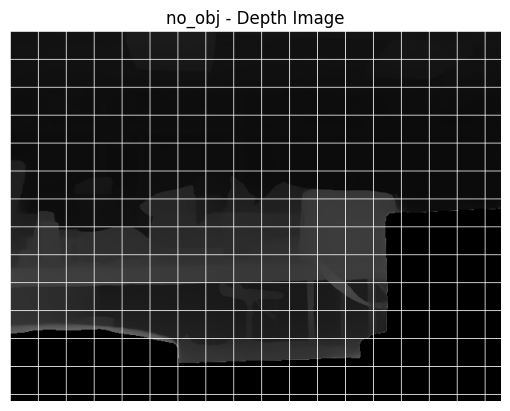

  0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00
 22.10 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |  12.44 |   0.57 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00
 59.16 |  54.65 |  55.02 |  33.00 |   0.00 |   0.00 |  29.67 |  31.58 |  21.86 |  26.69 |  40.70 |  53.68 |  52.30 |  48.75
 37.48 |  37.66 |  40.03 |  29.02 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |  38.30 |  70.07 |  68.10 |  65.35 |  64.57
 15.69 |  17.87 |  21.65 |  16.65 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |  34.55 |  54.83 |  53.38 |  53.05 |  52.36
  9.15 |  12.03 |  14.15 |  12.54 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |  35.57 |  52.12 |  51.21 |  50.95 |  50.61
  7.79 |  10.00 |  11.67 |  10.99 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |  38.46 |  52.61 |  51.38 |  50.92 |  50.91
 21.67 |  25.21 |  13.55 |  13.09 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |  41.17 |  52.05 |  50.59 |  49.63 |  48.90
 13.29 |

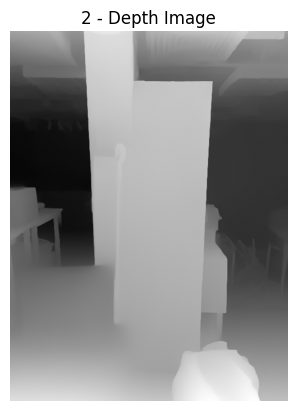

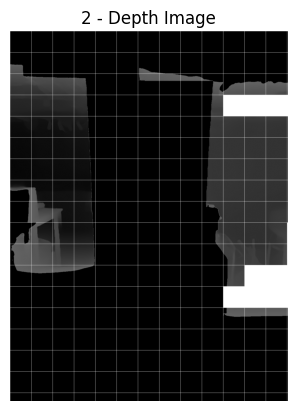

 30.50 |  15.29 |  15.76 |  15.96 |  18.68 |  19.06 |  19.22 |  17.01 |  15.99 |  15.84 |  15.91 |  16.10 |  16.17 |  17.17 |  17.57 |  17.42 |  16.65 |  16.60
 37.65 |  13.71 |  13.71 |  14.13 |  14.90 |  15.40 |  15.58 |  14.83 |  14.44 |  14.19 |  13.61 |  13.69 |  14.32 |  14.82 |  15.03 |  15.40 |  14.28 |  13.90
 41.76 |  12.21 |  12.19 |  12.70 |  12.43 |  12.32 |  12.85 |  13.14 |  11.07 |  11.21 |  12.42 |  12.36 |  12.23 |  12.16 |  12.74 |  13.10 |  12.60 |  12.28
 44.05 |  12.26 |  12.26 |  13.38 |  12.68 |  12.44 |  12.61 |  12.77 |  10.16 |   5.59 |  13.40 |  79.78 |  58.19 |  37.28 |  12.01 |  12.21 |  12.00 |  12.01
 23.67 |  12.00 |  12.00 |  12.50 |  12.28 |  14.92 |  31.67 |  45.93 |  58.75 |  77.06 |  93.13 |  96.90 |  98.58 |  97.60 |  70.26 |  54.75 |  50.62 |  45.98
 17.46 |  12.00 |  13.15 |  13.01 |  19.31 |  85.04 |  90.37 |  88.99 |  88.64 |  90.14 |  91.08 |  93.80 |  96.59 |  97.20 |  65.46 |  96.99 |  95.95 |  96.59
 18.50 |  17.35 |  12.00 |  12.13 |  60.

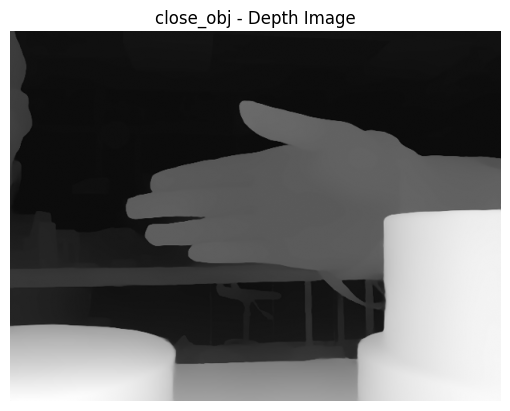

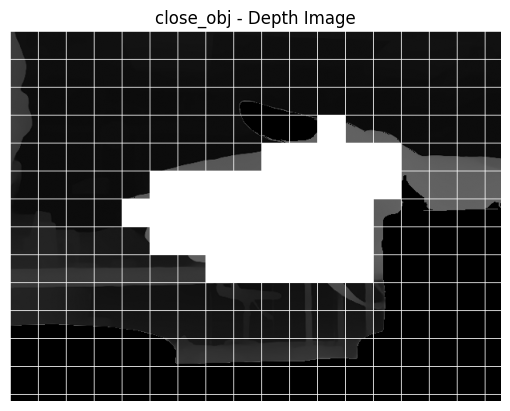

 79.08 |  40.56 |  16.35 |  16.98 |  20.81 |  21.48 |  21.80 |  18.76 |  17.45 |  17.09 |  17.10 |  17.20 |  17.29 |  18.81 |  19.57 |  19.07 |  17.97 |  17.85
 86.17 |  80.40 |  50.07 |  18.10 |  16.08 |  16.79 |  16.94 |  15.84 |  15.71 |  15.35 |  14.99 |  15.15 |  15.57 |  16.58 |  16.77 |  16.54 |  15.32 |  15.01
 82.80 |  78.72 |  73.42 |  52.37 |  14.82 |  12.96 |  13.27 |  13.29 |  13.22 |  13.22 |  13.12 |  13.23 |  12.88 |  13.01 |  13.37 |  13.87 |  13.16 |  12.58
 64.13 |  71.24 |  69.77 |  65.82 |  50.49 |  17.89 |  12.77 |  12.84 |  13.17 |  12.99 |  12.82 |  12.97 |  12.84 |  12.43 |  12.35 |  12.44 |  12.35 |  12.11
 15.93 |  14.94 |  17.23 |  32.39 |  53.60 |  58.64 |  36.07 |  32.27 |  16.58 |  12.26 |  12.03 |  12.00 |  12.61 |  12.00 |  12.00 |  12.00 |  12.00 |  12.11
 19.80 |  14.99 |  15.18 |  14.36 |  13.55 |  26.11 |  51.78 |  57.11 |  31.10 |  16.32 |  20.10 |  23.25 |  22.71 |  17.16 |  12.05 |  12.12 |  12.02 |  12.17
 25.19 |  21.84 |  14.99 |  14.46 |  16.

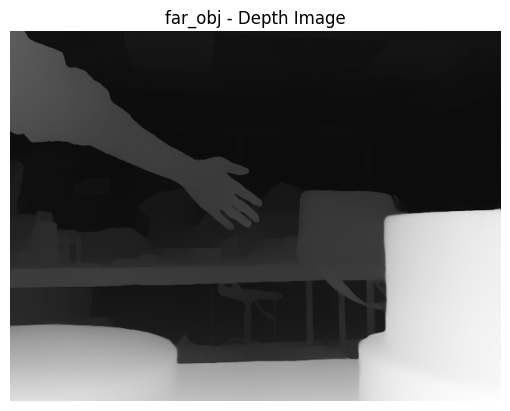

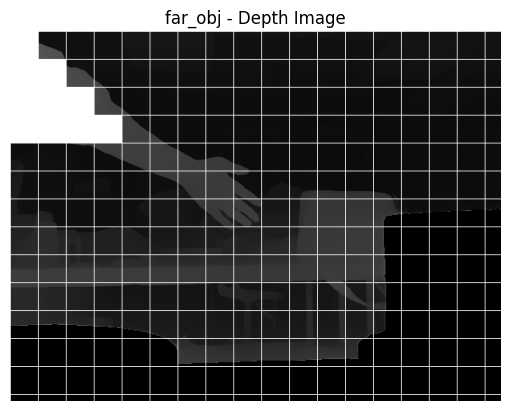

 76.87 |  76.85 |  77.34 |  77.92 |  82.25 |  47.39 |  64.20 |   0.00 |   0.00 |   0.00 |  37.78 |  61.50 |   2.70 |   0.00
 75.10 |  78.18 |  82.13 |  67.79 |  67.10 |  11.97 |  35.06 |   0.00 |   0.00 |   0.00 |  27.53 |  32.07 |   0.29 |   4.46
 87.21 |  91.44 |  86.87 |  76.65 |  53.46 |  52.88 |  44.10 |   0.00 |   0.00 |   0.00 |  25.72 |  36.22 |  35.32 |  51.32
 86.65 |  86.64 |  59.21 |  53.72 |  46.81 |  45.54 |  36.39 |   0.00 |   0.00 |   0.00 |  29.11 |  38.62 |  38.05 |  38.80
 42.55 |  47.88 |  43.62 |  42.38 |  42.83 |  43.90 |  33.28 |   0.00 |   0.00 |   0.00 |  25.28 |  32.60 |  34.80 |  35.55
 19.08 |  39.39 |  32.82 |  34.39 |  32.56 |  37.54 |  31.00 |   0.00 |   0.00 |   0.00 |  18.39 |  26.20 |  31.95 |  33.54
 16.87 |  38.06 |  32.97 |  33.68 |  30.73 |  35.55 |  29.30 |   0.00 |   0.00 |   0.03 |  17.12 |  24.36 |  29.99 |  32.01
 24.57 |  37.34 |  32.30 |  32.30 |  30.36 |  35.01 |  26.85 |   0.00 |   0.00 |   2.74 |  67.59 |  67.32 |  74.22 |  74.80
 33.88 |

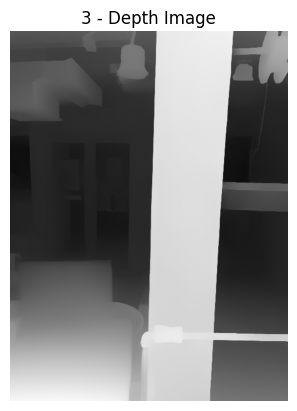

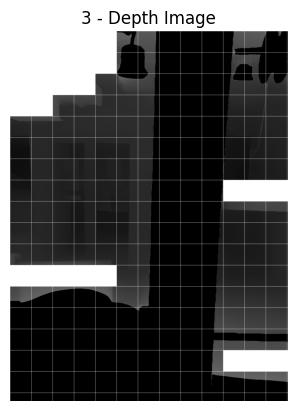

In [2]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import cv2
from matplotlib import pyplot as plt
import os

# Get all image paths from the folder PIC
image_folder = "PIC"
image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Load images
images = [Image.open(img_path).convert("RGB") for img_path in image_paths]
titles = [os.path.basename(img_path).split('.')[0] for img_path in image_paths]

image_processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")
model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")

for img, title in zip(images, titles):
    # prepare image for the model
    inputs = image_processor(images=img, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # interpolate to original size and visualize the prediction
    post_processed_output = image_processor.post_process_depth_estimation(
        outputs,
        target_sizes=[(img.height, img.width)],
    )

    predicted_depth = post_processed_output[0]["predicted_depth"]
    depth = (predicted_depth - predicted_depth.min()) / (predicted_depth.max() - predicted_depth.min())
    depth = depth.detach().cpu().numpy() * 255
    depth = Image.fromarray(depth.astype("uint8"))

    # Convert PIL image to numpy array
    depth_np = np.array(depth)
    # Copy the original depth image for compare
    org_np = np.copy(depth_np)

    # Mask the object in front to 0
    class3 = (depth_np >= 100) & (depth_np <= 255)
    high_value_indices = np.where(class3)
    depth_np[high_value_indices] = 0
    
    # Divide the image into equal regions
    height, width = depth_np.shape
    block_size = min(height, width) // 13  # Adjust the divisor to change the number of blocks
    num_blocks_x = width // block_size
    num_blocks_y = height // block_size
    
    blocks = []
    for y in range(0, height, block_size):
        for x in range(0, width, block_size):
            block = depth_np[y:y + block_size, x:x + block_size]
            blocks.append(block)

    # Calculate the mean value of grey scale for each block
    mean_values = [np.mean(block) for block in blocks]

    # Print the mean values in row and column order, in formatted manner
    num_blocks_x = width // block_size + 1 # padding/trunc
    num_blocks_y = height // block_size + 1
    for row in range(num_blocks_y):
        row_values = []
        for col in range(num_blocks_x):
            row_values.append(f"{mean_values[row * num_blocks_x + col]:6.2f}")
        print(" | ".join(row_values))
        
    # Draw lines around each block
    for y in range(0, height, block_size):
        for x in range(0, width, block_size):
            cv2.rectangle(depth_np, (x, y), (x + block_size, y + block_size), (255, 255, 255), 1)

    # Check if 4 or above neighboring blocks have similar mean values and are larger than a threshold
    tensity_threshold = 70
    surface_size_threshold = 4
    # Find linked blocks, put the number of linked blocks and the indices of linked blocks inside
    linked_blocks = []

    # check all neighbors of a block (left, right, top, bottom) and return the indices of qualified (intensity > threshold & is similar) neighbors
    def check_neighbors(index, mean_values, checked_indices, threshold=60):
        neighbors = []
        if index % num_blocks_x != 0:  # left neighbor
            neighbors.append(index - 1)
        if (index + 1) % num_blocks_x != 0:  # right neighbor
            neighbors.append(index + 1)
        if index >= num_blocks_x:  # top neighbor
            neighbors.append(index - num_blocks_x)
        if index < len(mean_values) - num_blocks_x:  # bottom neighbor
            neighbors.append(index + num_blocks_x)
        
        qualified_neighbors = [i for i in neighbors if abs(mean_values[i] - mean_values[index]) < 20 and mean_values[i] > threshold and i not in checked_indices]
        return qualified_neighbors

    # check all blocks, skip the blocks that have been checked (include check neighbor function)
    checked_indices = set()
    for i in range(len(mean_values)):
        if i in checked_indices:
            continue
        #  check the neighbour, if the neighbour is qualified, check the further neighbours, until no more qualified neighbours (in stack)
        if mean_values[i] > tensity_threshold:
            stack = [i]
            qualified_neighbors = []
            while stack:
                current = stack.pop()
                if current not in checked_indices:
                    checked_indices.add(current)
                    qualified_neighbors.append(current)
                    further_neighbors = check_neighbors(current, mean_values, checked_indices)
                    stack.extend(further_neighbors)
            if len(qualified_neighbors) >= surface_size_threshold:
                linked_blocks.append((len(qualified_neighbors), qualified_neighbors))

    # Highlight linked blocks in the image by setting them to 255
    for _, block_indices in linked_blocks:
        for index in block_indices:
            y = (index // num_blocks_x) * block_size
            x = (index % num_blocks_x) * block_size
            depth_np[y:y + block_size, x:x + block_size] = 255

    print("Number of Linked Blocks:", len(linked_blocks), "\nregion size:", end='')
    for size, block_indices in linked_blocks:
        print(size, end=' ')
    print()

    # if there are only one linked region, check if it has close surface
    have_close_surface = False
    # Print the coordinates of linked blocks
    for _, block_indices in linked_blocks:
        coordinates = [(index % num_blocks_x, index // num_blocks_x) for index in block_indices]
        print("Linked Block Coordinates:", coordinates)
        if len(linked_blocks) == 1:
            have_close_surface = True
        else:
            # check if the linked blocks (more than one) is actually linked together
            all_linked = True
            for i in range(len(linked_blocks) - 1):
                for j in range(i + 1, len(linked_blocks)):
                    if not any(abs(a % num_blocks_x - b % num_blocks_x) <= 1 and abs(a // num_blocks_x - b // num_blocks_x) <= 1 for a in linked_blocks[i][1] for b in linked_blocks[j][1]):
                        all_linked = False
                        break
                if not all_linked:
                    break
            if all_linked:
                have_close_surface = True
                
    if have_close_surface:
        print("yes")
    else:
        print("no")
        
    highlighted_percentage = np.sum(depth_np == 255) / depth_np.size * 100
    print(f"Highlighted Region Percentage: {highlighted_percentage:.2f}%")

    plt.imshow(org_np, cmap='gray')
    plt.title(f'{title} - Depth Image')
    plt.axis('off')
    plt.show()

    plt.imshow(depth_np, cmap='gray')
    plt.title(f'{title} - Depth Image')
    plt.axis('off')
    plt.show()